# EBRAINS BrainScaleS-2 TTFS neuron-pooling experiment

Use the `EBRAINS-experimental` kernel and execute cells in order. This notebook is a thin launcher for the repository CLI. It deliberately does **not** install the full project `requirements.txt`, upgrade `torch`, or install `hxtorch`.

## 1. Install only notebook-side dependencies

`%pip` targets the active Jupyter kernel. The BrainScaleS-2 software stack remains the version supplied by EBRAINS.

In [1]:
%pip install --quiet --disable-pip-version-check jaxtyping matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Locate the repository and select run stages

CADC diagnosis, a small operating-point sweep, hardware smoke, and the full pooling experiment are enabled by default; `Run All` therefore requests shared hardware and proceeds through the accepted operating point into the complete condition grid.

In [2]:
from datetime import datetime, timezone
from pathlib import Path
import csv
import json
import os
import subprocess
import sys

start = Path.cwd().resolve()
repo_root = next(
    (
        candidate
        for candidate in (start, *start.parents)
        if (candidate / "scripts/evaluation/brainscales2_pooling.py").is_file()
    ),
    None,
)
if repo_root is None:
    raise RuntimeError("Could not locate the delayed-temporal repository root")
os.chdir(repo_root)

RUN_MOCK_SMOKE = True
RUN_CADC_DIAGNOSTIC = True
RUN_HARDWARE_SMOKE = True
RUN_OPERATING_POINT_SWEEP = True
RUN_FULL_EXPERIMENT = True

# Formal full runs require an explicit, immutable .pbin calibration.
CALIBRATION_PATH = None  # Example: Path("/mnt/user/shared/calibration/spiking_calibration.pbin")
DEMOS_ROOT = Path("/tmp/brainscales2-demos")
RUN_LABEL = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
ARTIFACT_ROOT = repo_root / "artifacts/brainscales2" / RUN_LABEL
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
SMOKE_CALIBRATION_PATH = ARTIFACT_ROOT / "spiking_cocolist.pbin"

print("repository:", repo_root)
print("python:", sys.executable)
print("artifacts:", ARTIFACT_ROOT)

repository: /mnt/user/shared/AnalogAttention
python: /srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/experimental/.spack-env/view/bin/python
artifacts: /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z


## 3. Check the active EBRAINS kernel

In [3]:
import inspect
import torch
import jaxtyping
import hxtorch
import hxtorch.spiking as hxsnn

print("Python:", sys.version)
print("torch:", torch.__version__)
print("hxtorch:", getattr(hxtorch, "__version__", "unknown"))
print("Experiment:", inspect.signature(hxsnn.Experiment))
print("Synapse:", inspect.signature(hxsnn.Synapse))
print("LIF:", inspect.signature(hxsnn.LIF))
print("run:", inspect.signature(hxsnn.run))

Python: 3.11.10 (main, Mar 17 2025, 22:16:01) [GCC 13.3.0]
torch: 2.5.1
hxtorch: unknown
Experiment: (mock: bool = False, dt: float = 1e-06, hw_routing_func=<_pygrenade_vx_network_routing.PortfolioRouter object at 0x7fd13db37970>) -> None
Synapse: (in_features: 'int', out_features: 'int', experiment: 'Experiment', execution_instance: 'Optional[ExecutionInstance]' = None, chip_coordinate: 'Optional[Tuple[grenade.common.ChipOnConnection, grenade.common.ConnectionOnExecutor]]' = None, device: 'str' = None, dtype: 'Type' = None, transform: 'Callable' = <function linear_saturating at 0x7fd13ddb74c0>, plasticity_rule: 'Optional[grenade.network.PlasticityRule]' = None) -> 'None'
LIF: (size: 'int', experiment: 'Experiment', leak: 'ModuleParameterType' = 80, reset: 'ModuleParameterType' = 80, threshold: 'ModuleParameterType' = 125, tau_mem: 'ModuleParameterType' = 1e-05, tau_syn: 'ModuleParameterType' = 1e-05, i_synin_gm: 'ModuleParameterType' = 500, membrane_capacitance: 'ModuleParameterType' 

## 4. Configure the EBRAINS hardware client

When any hardware stage is enabled, this cell configures the client and saves the official nightly calibration into the run directory. Smoke stages load that `.pbin` explicitly, avoiding an implicit full-chip calibration.

In [4]:
hardware_requested = any(
    (
        RUN_HARDWARE_SMOKE,
        RUN_CADC_DIAGNOSTIC,
        RUN_OPERATING_POINT_SWEEP,
        RUN_FULL_EXPERIMENT,
    )
)

if hardware_requested:
    if not DEMOS_ROOT.is_dir():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "jupyter-notebooks-experimental",
                "https://github.com/electronicvisions/brainscales2-demos.git",
                str(DEMOS_ROOT),
            ],
            check=True,
        )
    if str(DEMOS_ROOT) not in sys.path:
        sys.path.insert(0, str(DEMOS_ROOT))
    from _static.common.helpers import save_nightly_calibration, setup_hardware_client
    setup_hardware_client()
    if not SMOKE_CALIBRATION_PATH.is_file():
        save_nightly_calibration(
            SMOKE_CALIBRATION_PATH.name,
            folder=str(SMOKE_CALIBRATION_PATH.parent),
        )
    if not SMOKE_CALIBRATION_PATH.is_file():
        raise FileNotFoundError(SMOKE_CALIBRATION_PATH)
    print("EBRAINS hardware client configured")
    print("smoke calibration:", SMOKE_CALIBRATION_PATH)
else:
    print("Hardware stages disabled; client setup skipped")

INFO  10:40:16,830  demo_helpers Connection to hxcube7fpga0chip57_1 established
EBRAINS hardware client configured
smoke calibration: /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/spiking_cocolist.pbin


## 5. CLI helpers

Every CLI subprocess uses the active kernel's exact Python executable and inherits the hardware-client environment.

In [5]:
CLI = repo_root / "scripts/evaluation/brainscales2_pooling.py"
VERIFY = repo_root / "scripts/verification/verify_brainscales2_pooling.py"

def run_python(script: Path, *arguments: object) -> None:
    command = [sys.executable, str(script), *(str(value) for value in arguments)]
    print(" ".join(command))
    subprocess.run(command, cwd=repo_root, check=True)

def show_artifacts(output_dir: Path) -> None:
    manifest_path = output_dir / "manifest.json"
    summary_path = output_dir / "summary.csv"
    if not manifest_path.is_file() or not summary_path.is_file():
        print("No completed artifacts:", output_dir)
        return
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    with summary_path.open(newline="", encoding="utf-8") as handle:
        summary = list(csv.DictReader(handle))
    print(json.dumps(
        {
            "schema_version": manifest.get("schema_version"),
            "conditions": len(manifest.get("conditions", [])),
            "environment": manifest.get("environment"),
        },
        indent=2,
    ))
    display(summary[:8])
    for figure_name in ("cadc_trace.png", "variance_fit.png"):
        figure = output_dir / figure_name
        if figure.is_file():
            from IPython.display import Image
            display(Image(filename=str(figure)))

## 6. Pure-Python verification

This validates encoding, routing shapes, miss-aware pooling, variance-floor recovery, artifacts, and notebook metadata without accessing hardware.

In [6]:
run_python(VERIFY)

/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/experimental/.spack-env/view/bin/python /mnt/user/shared/AnalogAttention/scripts/verification/verify_brainscales2_pooling.py
BrainScaleS-2 TTFS pooling verification passed


## 7. Mock quick smoke

This runs three potential positions, pool sizes 1 and 4, one placement/routing condition, and eight trials.

/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/experimental/.spack-env/view/bin/python /mnt/user/shared/AnalogAttention/scripts/evaluation/brainscales2_pooling.py --backend mock --quick --output-dir /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/mock_quick
Running M=1 placement=same-quadrant routing=broadcast
Running M=4 placement=same-quadrant routing=broadcast
Wrote BrainScaleS-2 pooling artifacts to /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/mock_quick
{
  "schema_version": 1,
  "conditions": 2,
  "environment": {
    "created_at": "2026-08-29T08:40:30.344231+00:00",
    "ebrains_release": null,
    "git_revision": "d55de5408ad232796ab41a2674ff9a6f51b7a59e",
    "platform": "Linux-6.1.0-52-amd64-x86_64-with-glibc2.39",
    "python": "3.11.10",
    "torch": "2.5.1"
  }
}


[{'pool_size': '1',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'corrected-mean',
  'evaluation_trials': '4',
  'valid_pools': '12',
  'all_miss_rate': '0.0',
  'neuron_miss_rate': '0.0',
  'multi_spike_rate': '0.0',
  'bias_s': '9.910787208825512e-08',
  'mae_s': '7.053092891671424e-07',
  'variance_s2': '1.0225271920996722e-12',
  'mean_pairwise_correlation': 'nan'},
 {'pool_size': '1',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'mean',
  'evaluation_trials': '4',
  'valid_pools': '12',
  'all_miss_rate': '0.0',
  'neuron_miss_rate': '0.0',
  'multi_spike_rate': '0.0',
  'bias_s': '9.910787208825569e-08',
  'mae_s': '7.053092891671421e-07',
  'variance_s2': '1.0225271920996712e-12',
  'mean_pairwise_correlation': 'nan'},
 {'pool_size': '1',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'median',
  'evaluation_trials': '4',
  'valid_pools': '12',
  'all_miss_rate': '0.0',
  'neuron_miss_rate': '0.0',

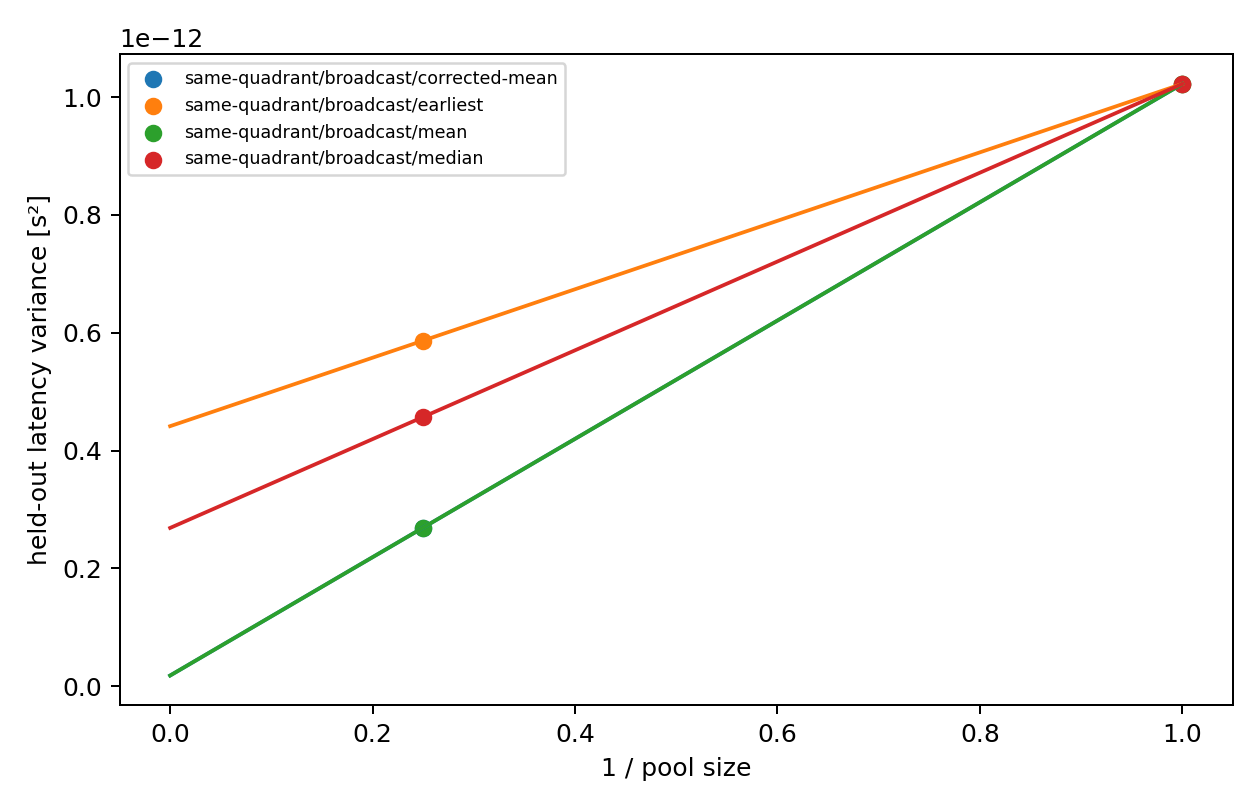

In [7]:
mock_dir = ARTIFACT_ROOT / "mock_quick"
if RUN_MOCK_SMOKE:
    run_python(
        CLI,
        "--backend", "mock",
        "--quick",
        "--output-dir", mock_dir,
    )
    show_artifacts(mock_dir)
else:
    print("Mock smoke disabled")

## 8. CADC single-PSP diagnostic

This follows the official hxtorch SNN introduction: compare no-input and one-input CADC membrane traces before attempting timing measurements. CADC is diagnostic only; final jitter still uses raw spike events.

/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/experimental/.spack-env/view/bin/python /mnt/user/shared/AnalogAttention/scripts/evaluation/brainscales2_pooling.py --phase diagnose-cadc --backend hardware --quick --calibration /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/spiking_cocolist.pbin --i-synin-gm 700 --output-dir /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/cadc_diagnostic
WARN  10:40:37,365  hxtorch.spiking.execution_instance.ExecutionInstance(ID=0) Tried to infer params from calib but no readable calibration present. This might be because a coco binary was indicated as calibration file. Skipped.
{
  "aggregate": {
    "baseline_fired_rate": 0.0,
    "maximum_threshold_gap_cadc": 12.67047170639038,
    "minimum_threshold_gap_cadc": 5.0,
    "noise_excursion_q99_cadc": 3.0,
    "psp_peak_median_cadc": 15.769580841064453,
    "psp_peak_q10_cadc": 14.906437301635743,
    "stimulated_fi

[{'neuron': '0',
  'physical_coordinate': '0',
  'baseline_cadc': '-40.53592252731323',
  'baseline_excursion_q99': '2.9132394027709956',
  'psp_peak_q10': '14.958000183105469',
  'psp_peak_median': '15.572580337524414',
  'baseline_fired_rate': '0.0',
  'stimulated_fired_rate': '0.0'},
 {'neuron': '1',
  'physical_coordinate': '1',
  'baseline_cadc': '-50.2649827003479',
  'baseline_excursion_q99': '2.461276969909668',
  'psp_peak_q10': '14.885318374633789',
  'psp_peak_median': '15.0',
  'baseline_fired_rate': '0.0',
  'stimulated_fired_rate': '0.0'},
 {'neuron': '2',
  'physical_coordinate': '2',
  'baseline_cadc': '-45.19293689727783',
  'baseline_excursion_q99': '2.919123382568359',
  'psp_peak_q10': '15.571198654174804',
  'psp_peak_median': '17.0',
  'baseline_fired_rate': '0.0',
  'stimulated_fired_rate': '0.0'},
 {'neuron': '3',
  'physical_coordinate': '3',
  'baseline_cadc': '-46.824429512023926',
  'baseline_excursion_q99': '2.0',
  'psp_peak_q10': '14.889997863769532',
  '

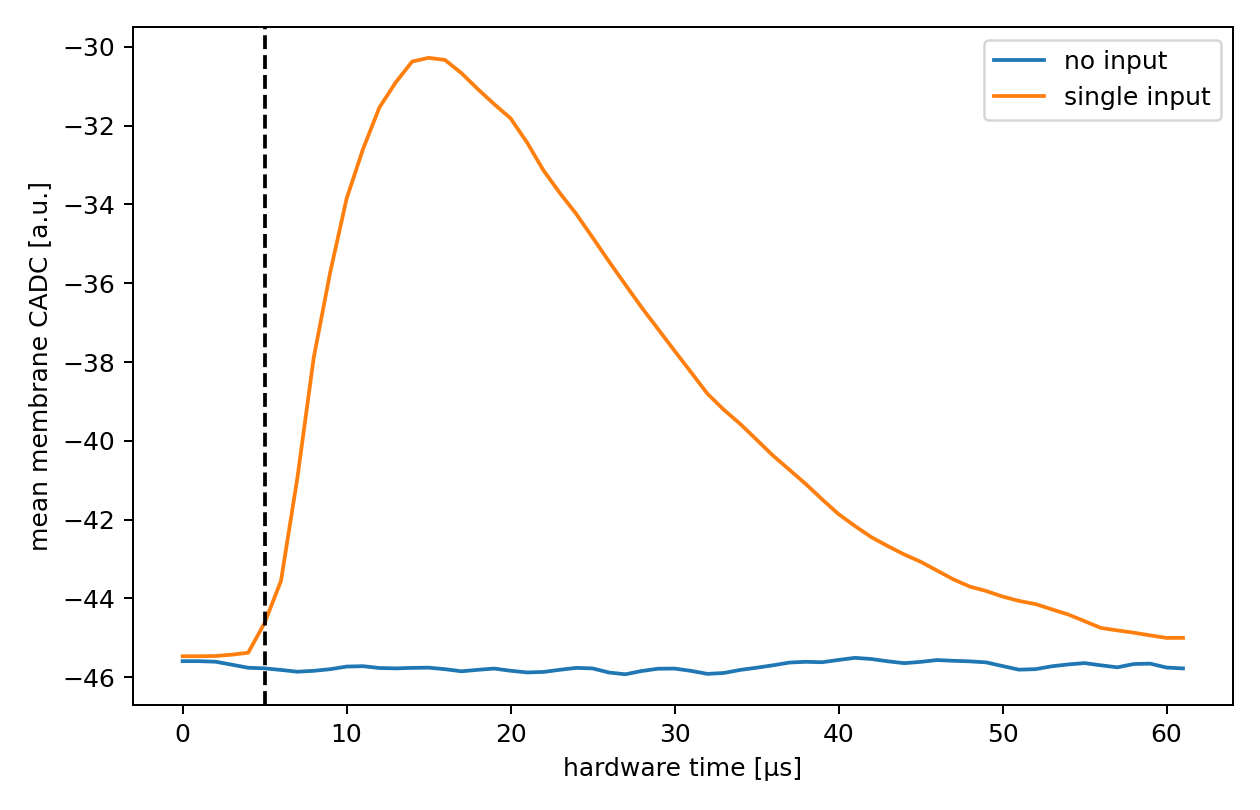

{'aggregate': {'baseline_fired_rate': 0.0,
  'maximum_threshold_gap_cadc': 12.67047170639038,
  'minimum_threshold_gap_cadc': 5.0,
  'noise_excursion_q99_cadc': 3.0,
  'psp_peak_median_cadc': 15.769580841064453,
  'psp_peak_q10_cadc': 14.906437301635743,
  'stimulated_fired_rate': 0.0},
 'config': {'allow_environment_calibration': False,
  'calibration_path': '/mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/spiking_cocolist.pbin',
  'dt_s': 1e-06,
  'encoding': 'identity',
  'i_synin_gm': 700.0,
  'input_early_s': 5e-06,
  'input_fan_in': 1,
  'input_late_s': 2.5e-05,
  'inter_batch_wait_s': 5e-05,
  'leak': 80.0,
  'mock_local_std_s': 8e-07,
  'mock_miss_probability': 0.01,
  'mock_response_delay_s': 5e-06,
  'mock_shared_std_s': 2.5e-07,
  'mock_static_std_s': 5e-07,
  'observation_deadline_s': 6e-05,
  'placements': ['same-quadrant'],
  'pool_sizes': [1, 4],
  'project_tau_s': 1.0,
  'raw_time_scale_s': None,
  'refractory_time_s': 1e-06,
  'reset': 80.0,
  

In [8]:
cadc_diagnostic_dir = ARTIFACT_ROOT / "cadc_diagnostic"
cadc_recommendation_path = cadc_diagnostic_dir / "recommended_operating_point.json"
if RUN_CADC_DIAGNOSTIC:
    run_python(
        CLI,
        "--phase", "diagnose-cadc",
        "--backend", "hardware",
        "--quick",
        "--calibration", SMOKE_CALIBRATION_PATH,
        "--i-synin-gm", 700,
        "--output-dir", cadc_diagnostic_dir,
    )
    show_artifacts(cadc_diagnostic_dir)
    diagnostic = json.loads(cadc_recommendation_path.read_text(encoding="utf-8"))
    display(diagnostic)
    if not diagnostic["viable"]:
        raise RuntimeError(
            f'{diagnostic["reason"]}; stop before raw-spike sweeps'
        )
else:
    print("CADC diagnostic disabled")

## 9. Raw-spike operating-point sweep

After CADC confirms a physical PSP, this quick sweep tests actual raw firing with 1--4 coincident synaptic fan-in lanes. The legacy hxtorch `.pbin` path fixes analog neuron parameters, so this stage does not pretend that requested threshold or gain values alter the chip. It rejects an all-miss or multi-spike selection before the jitter smoke.

In [9]:
operating_point_dir = ARTIFACT_ROOT / "operating_point"
selected_path = operating_point_dir / "selected_operating_point.json"
if RUN_OPERATING_POINT_SWEEP:
    run_python(
        CLI,
        "--phase", "calibrate",
        "--backend", "hardware",
        "--quick",
        "--calibration", SMOKE_CALIBRATION_PATH,
        "--calibration-thresholds", 125,
        "--calibration-weights", 63,
        "--calibration-gains", 500,
        "--calibration-fan-ins", 1, 2, 3, 4,
        "--output-dir", operating_point_dir,
    )
    selection = json.loads(selected_path.read_text(encoding="utf-8"))
    display(selection)
    selected = selection["selected"]
    if (
        selected["fired_rate"] < 0.8
        or selected["multi_spike_rate"] > 0.05
        or selected["premature_spike_rate"] > 0.05
    ):
        raise RuntimeError(
            f"No usable raw-spike operating point in the quick grid: {selected}"
        )
else:
    print("Operating-point sweep disabled")

/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/experimental/.spack-env/view/bin/python /mnt/user/shared/AnalogAttention/scripts/evaluation/brainscales2_pooling.py --phase calibrate --backend hardware --quick --calibration /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/spiking_cocolist.pbin --calibration-thresholds 125 --calibration-weights 63 --calibration-gains 500 --calibration-fan-ins 1 2 3 4 --output-dir /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/operating_point
WARN  10:40:47,013  hxtorch.spiking.execution_instance.ExecutionInstance(ID=0) Tried to infer params from calib but no readable calibration present. This might be because a coco binary was indicated as calibration file. Skipped.
{'threshold': 125.0, 'synaptic_weight': 63.0, 'i_synin_gm': 500.0, 'input_fan_in': 1, 'analog_parameter_control': 'fixed-by-pinned-calibration', 'requested_analog_parameters_applied': False, 'fired_rate':

{'config': {'allow_environment_calibration': False,
  'calibration_path': '/mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/spiking_cocolist.pbin',
  'dt_s': 1e-06,
  'encoding': 'identity',
  'i_synin_gm': 500.0,
  'input_early_s': 5e-06,
  'input_fan_in': 1,
  'input_late_s': 2.5e-05,
  'inter_batch_wait_s': 5e-05,
  'leak': 80.0,
  'mock_local_std_s': 8e-07,
  'mock_miss_probability': 0.01,
  'mock_response_delay_s': 5e-06,
  'mock_shared_std_s': 2.5e-07,
  'mock_static_std_s': 5e-07,
  'observation_deadline_s': 6e-05,
  'placements': ['same-quadrant'],
  'pool_sizes': [1, 4],
  'project_tau_s': 1.0,
  'raw_time_scale_s': None,
  'refractory_time_s': 1e-06,
  'reset': 80.0,
  'routings': ['broadcast'],
  'seed': 0,
  'synapse_dac_bias': 600.0,
  'synaptic_weight': 63.0,
  'tau_mem_s': 2e-05,
  'tau_syn_s': 1e-06,
  'threshold': 125.0,
  'trials': 8},
 'environment': {'created_at': '2026-08-29T08:40:55.203360+00:00',
  'ebrains_release': None,
  'git_revision'

## 10. Hardware quick smoke

This runs only after CADC confirms a measurable PSP and the raw-spike sweep selects a firing operating point. It reuses that selected point instead of the previous all-miss defaults.

/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/experimental/.spack-env/view/bin/python /mnt/user/shared/AnalogAttention/scripts/evaluation/brainscales2_pooling.py --backend hardware --quick --calibration /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/spiking_cocolist.pbin --operating-point-json /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/operating_point/selected_operating_point.json --output-dir /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/hardware_smoke
Running M=1 placement=same-quadrant routing=broadcast
WARN  10:41:01,052  hxtorch.spiking.execution_instance.ExecutionInstance(ID=0) Tried to infer params from calib but no readable calibration present. This might be because a coco binary was indicated as calibration file. Skipped.
Running M=4 placement=same-quadrant routing=broadcast
WARN  10:41:03,138  hxtorch.spiking.execution_instance.ExecutionInstance(ID=1) Tr

[{'pool_size': '1',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'corrected-mean',
  'evaluation_trials': '4',
  'valid_pools': '12',
  'all_miss_rate': '0.0',
  'neuron_miss_rate': '0.0',
  'multi_spike_rate': '0.0',
  'bias_s': '-2.5333333333332978e-08',
  'mae_s': '5.099999999999946e-08',
  'variance_s2': '3.775515151515077e-15',
  'mean_pairwise_correlation': 'nan'},
 {'pool_size': '1',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'mean',
  'evaluation_trials': '4',
  'valid_pools': '12',
  'all_miss_rate': '0.0',
  'neuron_miss_rate': '0.0',
  'multi_spike_rate': '0.0',
  'bias_s': '-2.5333333333332554e-08',
  'mae_s': '5.099999999999931e-08',
  'variance_s2': '3.775515151515126e-15',
  'mean_pairwise_correlation': 'nan'},
 {'pool_size': '1',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'median',
  'evaluation_trials': '4',
  'valid_pools': '12',
  'all_miss_rate': '0.0',
  'neuron_miss_rate': '0.0

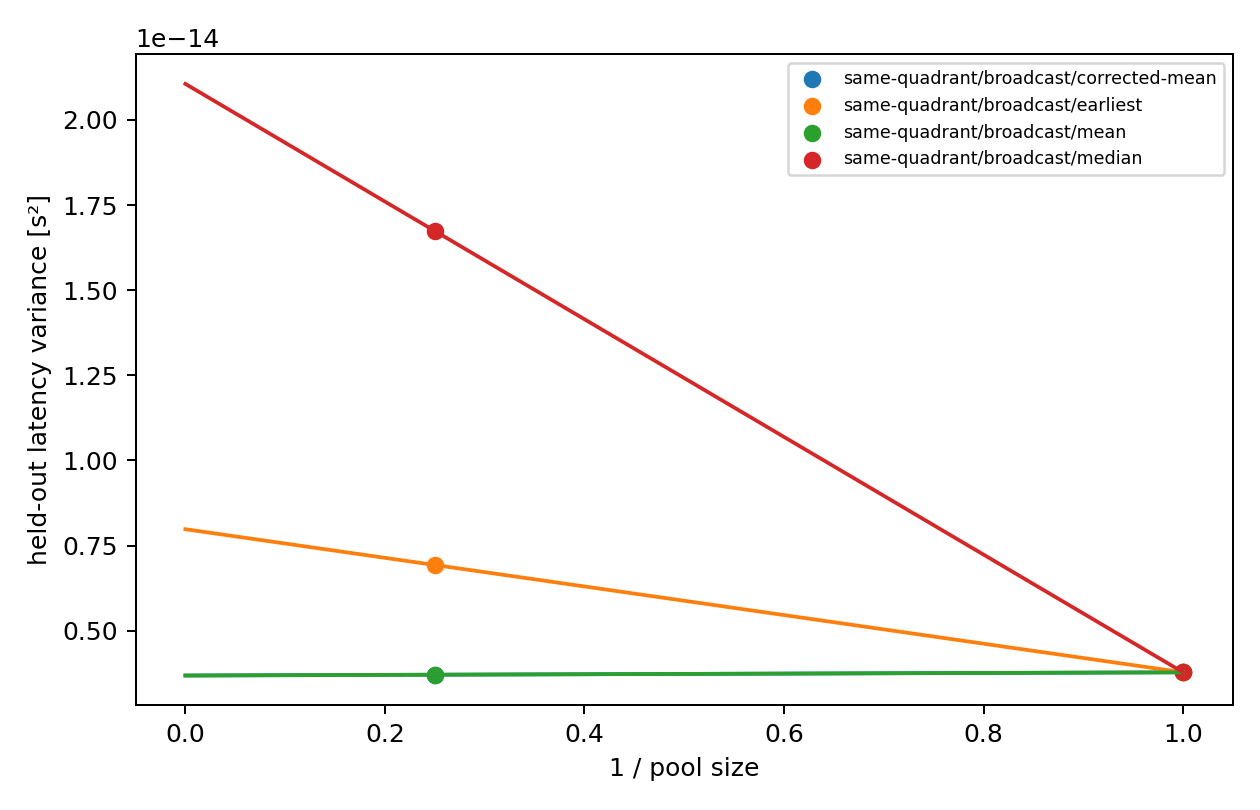

In [10]:
hardware_smoke_dir = ARTIFACT_ROOT / "hardware_smoke"
if RUN_HARDWARE_SMOKE:
    if not selected_path.is_file():
        raise FileNotFoundError(f"Run the operating-point sweep first: {selected_path}")
    run_python(
        CLI,
        "--backend", "hardware",
        "--quick",
        "--calibration", SMOKE_CALIBRATION_PATH,
        "--operating-point-json", selected_path,
        "--output-dir", hardware_smoke_dir,
    )
    show_artifacts(hardware_smoke_dir)
else:
    print("Hardware smoke disabled")

## 11. Formal pooling experiment

The full experiment uses `CALIBRATION_PATH` when supplied and otherwise reuses the run-local `.pbin` already pinned by the diagnostic and smoke stages. It runs pool sizes 1, 2, 4, 8, and 16 across both placement and routing conditions with 256 trials.

/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/experimental/.spack-env/view/bin/python /mnt/user/shared/AnalogAttention/scripts/evaluation/brainscales2_pooling.py --backend hardware --encoding identity --pool-sizes 1 2 4 8 16 --placements same-quadrant cross-quadrant --routing broadcast independent --trials 256 --calibration /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/spiking_cocolist.pbin --operating-point-json /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/operating_point/selected_operating_point.json --output-dir /mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/full_pooling
Running M=1 placement=same-quadrant routing=broadcast
WARN  10:41:13,078  hxtorch.spiking.execution_instance.ExecutionInstance(ID=0) Tried to infer params from calib but no readable calibration present. This might be because a coco binary was indicated as calibration file. Skipped.
Running M=2 pl

[{'pool_size': '1',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'corrected-mean',
  'evaluation_trials': '128',
  'valid_pools': '1408',
  'all_miss_rate': '0.0',
  'neuron_miss_rate': '0.0',
  'multi_spike_rate': '0.0',
  'bias_s': '-6.518750000000009e-08',
  'mae_s': '1.2080628551136364e-07',
  'variance_s2': '1.7232890191897638e-14',
  'mean_pairwise_correlation': 'nan'},
 {'pool_size': '1',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'mean',
  'evaluation_trials': '128',
  'valid_pools': '1408',
  'all_miss_rate': '0.0',
  'neuron_miss_rate': '0.0',
  'multi_spike_rate': '0.0',
  'bias_s': '-6.518750000000009e-08',
  'mae_s': '1.2080628551136364e-07',
  'variance_s2': '1.7232890191897638e-14',
  'mean_pairwise_correlation': 'nan'},
 {'pool_size': '1',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'median',
  'evaluation_trials': '128',
  'valid_pools': '1408',
  'all_miss_rate': '0.0',
  'neuron_mi

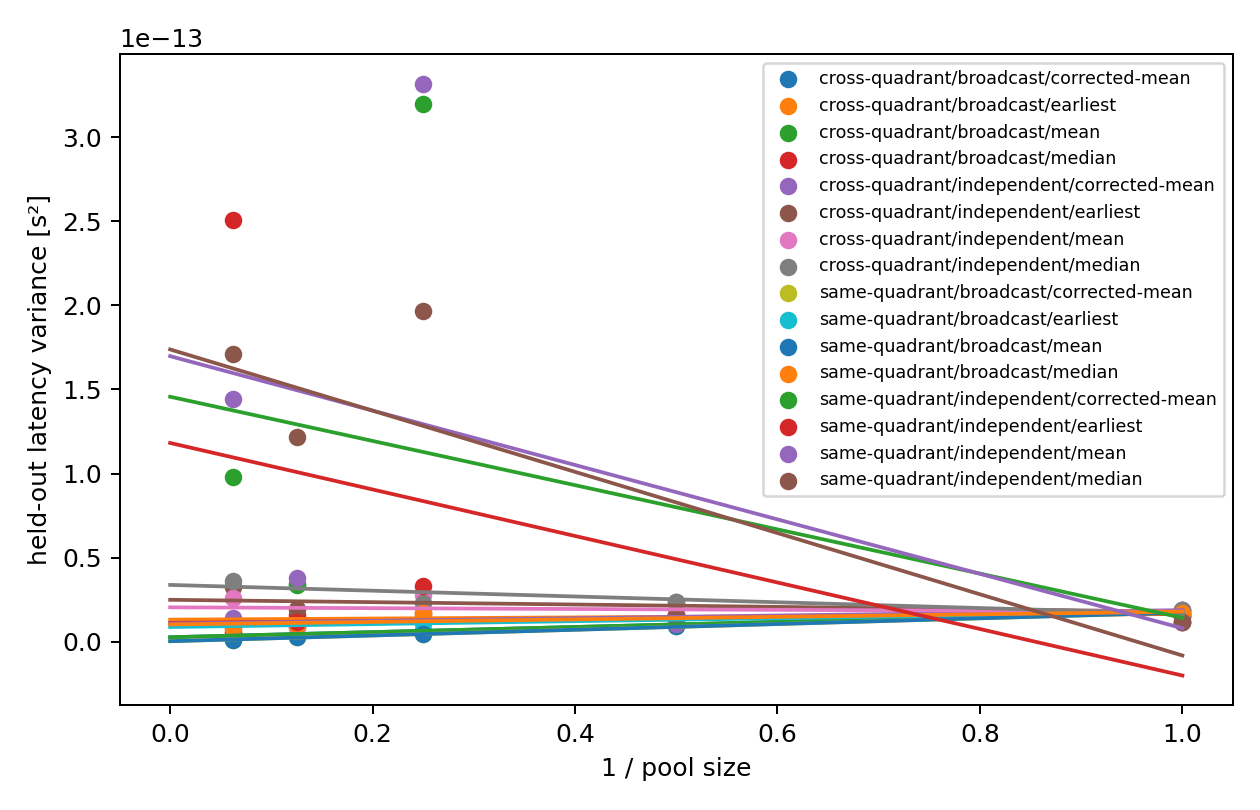

In [11]:
full_dir = ARTIFACT_ROOT / "full_pooling"
selected_path = operating_point_dir / "selected_operating_point.json"

if RUN_FULL_EXPERIMENT:
    calibration_path = (
        Path(CALIBRATION_PATH).expanduser().resolve()
        if CALIBRATION_PATH is not None
        else SMOKE_CALIBRATION_PATH.resolve()
    )
    if not calibration_path.is_file():
        raise FileNotFoundError(calibration_path)
    if not selected_path.is_file():
        raise FileNotFoundError(
            f"Run the operating-point sweep first: {selected_path}"
        )
    run_python(
        CLI,
        "--backend", "hardware",
        "--encoding", "identity",
        "--pool-sizes", 1, 2, 4, 8, 16,
        "--placements", "same-quadrant", "cross-quadrant",
        "--routing", "broadcast", "independent",
        "--trials", 256,
        "--calibration", calibration_path,
        "--operating-point-json", selected_path,
        "--output-dir", full_dir,
    )
    show_artifacts(full_dir)
else:
    print("Full experiment disabled")

## 12. Result locations

Download or persist the complete run directory, including `manifest.json`, raw `events.csv`, `events.pt`, summaries, variance fit, and figure.

In [12]:
for path in sorted(ARTIFACT_ROOT.glob("*")):
    print(path)

/mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/cadc_diagnostic
/mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/full_pooling
/mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/hardware_smoke
/mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/mock_quick
/mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/operating_point
/mnt/user/shared/AnalogAttention/artifacts/brainscales2/20260829T084007Z/spiking_cocolist.pbin


In [13]:
with open(full_dir / "variance_fit.csv") as f:
    fit_rows = list(csv.DictReader(f))

display([
    row for row in fit_rows
    if row["estimator"] == "corrected-mean"
])

[{'a_s2': '1.7015765329067873e-14',
  'c_s2': '3.496095196198514e-16',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'corrected-mean',
  'a_ci_low_s2': '1.442705184576898e-14',
  'a_ci_high_s2': '1.9291632867827146e-14',
  'c_ci_low_s2': '-2.0816478766352474e-16',
  'c_ci_high_s2': '9.145988579042154e-16'},
 {'a_s2': '-1.314416732679386e-13',
  'c_s2': '1.4568604379826604e-13',
  'placement': 'same-quadrant',
  'routing': 'independent',
  'estimator': 'corrected-mean',
  'a_ci_low_s2': '-1.3919296946392183e-13',
  'a_ci_high_s2': '-1.2434297907703367e-13',
  'c_ci_low_s2': '1.3775352597817976e-13',
  'c_ci_high_s2': '1.5438875281428526e-13'},
 {'a_s2': '1.5220165328665005e-14',
  'c_s2': '2.7005172525012677e-15',
  'placement': 'cross-quadrant',
  'routing': 'broadcast',
  'estimator': 'corrected-mean',
  'a_ci_low_s2': '1.3385375517836601e-14',
  'a_ci_high_s2': '1.7007633583309406e-14',
  'c_ci_low_s2': '2.1395839066266186e-15',
  'c_ci_high_s2': '3.1855994

In [14]:
with open(full_dir / "summary.csv") as f:
    summary_rows = list(csv.DictReader(f))

display([
    row for row in summary_rows
    if row["estimator"] == "corrected-mean"
])

[{'pool_size': '1',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'corrected-mean',
  'evaluation_trials': '128',
  'valid_pools': '1408',
  'all_miss_rate': '0.0',
  'neuron_miss_rate': '0.0',
  'multi_spike_rate': '0.0',
  'bias_s': '-6.518750000000009e-08',
  'mae_s': '1.2080628551136364e-07',
  'variance_s2': '1.7232890191897638e-14',
  'mean_pairwise_correlation': 'nan'},
 {'pool_size': '2',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'corrected-mean',
  'evaluation_trials': '128',
  'valid_pools': '1408',
  'all_miss_rate': '0.0',
  'neuron_miss_rate': '0.0',
  'multi_spike_rate': '0.0',
  'bias_s': '3.186079545454509e-08',
  'mae_s': '8.103524502840903e-08',
  'variance_s2': '9.163889279253079e-15',
  'mean_pairwise_correlation': '-0.01426520146806065'},
 {'pool_size': '4',
  'placement': 'same-quadrant',
  'routing': 'broadcast',
  'estimator': 'corrected-mean',
  'evaluation_trials': '128',
  'valid_pools': '1408',
  'all